# Рубежный контроль №2 Гайнуллин А.М. ИУ5-62Б
Методы построения моделей машинного обучения.  
  
Задание. Для заданного набора данных (по Вашему варианту) постройте модели классификации или регрессии (в зависимости от конкретной задачи, рассматриваемой в наборе данных). Для построения моделей используйте методы 1 и 2 (по варианту для Вашей группы). Оцените качество моделей на основе подходящих метрик качества (не менее двух метрик). Какие метрики качества Вы использовали и почему? Какие выводы Вы можете сделать о качестве построенных моделей? Для построения моделей необходимо выполнить требуемую предобработку данных: заполнение пропусков, кодирование категориальных признаков, и т.д.  
  
Методы:1 - Метод опорных векторов, 2 - Случайный лес.  
Датасет: https://www.kaggle.com/datasets/altavish/boston-housing-dataset  

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Загрузка данных
Используем датасет Boston Housing из CSV-файла.

In [30]:
df = pd.read_csv('BostonHousing.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


## 2. Предварительная обработка данных
Проверим пропуски, при необходимости заполним их.
В датасете нет категориальных признаков, все числовые.

In [31]:
print('Пропуски по столбцам:')
print(df.isnull().sum())

Пропуски по столбцам:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [32]:
# Если бы были пропуски, их можно было бы заполнить, например, медианой:
# df.fillna(df.median(), inplace=True)
# Но в данном случае пропусков нет.

## 3. Разделение на обучающую и тестовую выборки

In [33]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

## 4. Масштабирование признаков
SVR чувствителен к масштабу, масштабируем данные.

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Обучение моделей

In [35]:
from sklearn.impute import SimpleImputer

#Импутация пропусков на тренировочной выборке
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)    # обучаем на тренировочных данных
X_test_imputed  = imputer.transform(X_test)         # применяем к тестовым

#Масштабирование (только для SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled  = scaler.transform(X_test_imputed)

#Обучение SVR
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)

# Обучение Random Forest 
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_imputed, y_train)

RandomForestRegressor(random_state=42)

## 6. Оценка качества моделей
Используем метрики:
- R² (коэффициент детерминации).
- MAE (Mean Absolute Error).
- RMSE (Root Mean Squared Error).

In [36]:
#Предсказания
y_pred_svr = svr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

#Функция для вычисления метрик
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

metrics_svr = evaluate(y_test, y_pred_svr)
metrics_rf = evaluate(y_test, y_pred_rf)

#Вывод результатов
results = pd.DataFrame([
    ['SVR'] + list(metrics_svr),
    ['Random Forest'] + list(metrics_rf)
], columns=['Модель', 'MAE', 'RMSE', 'R2'])
results

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


,Модель,MAE,RMSE,R2
0,SVR,2.769549,5.142733,0.639352
1,Random Forest,2.036431,2.905724,0.884866


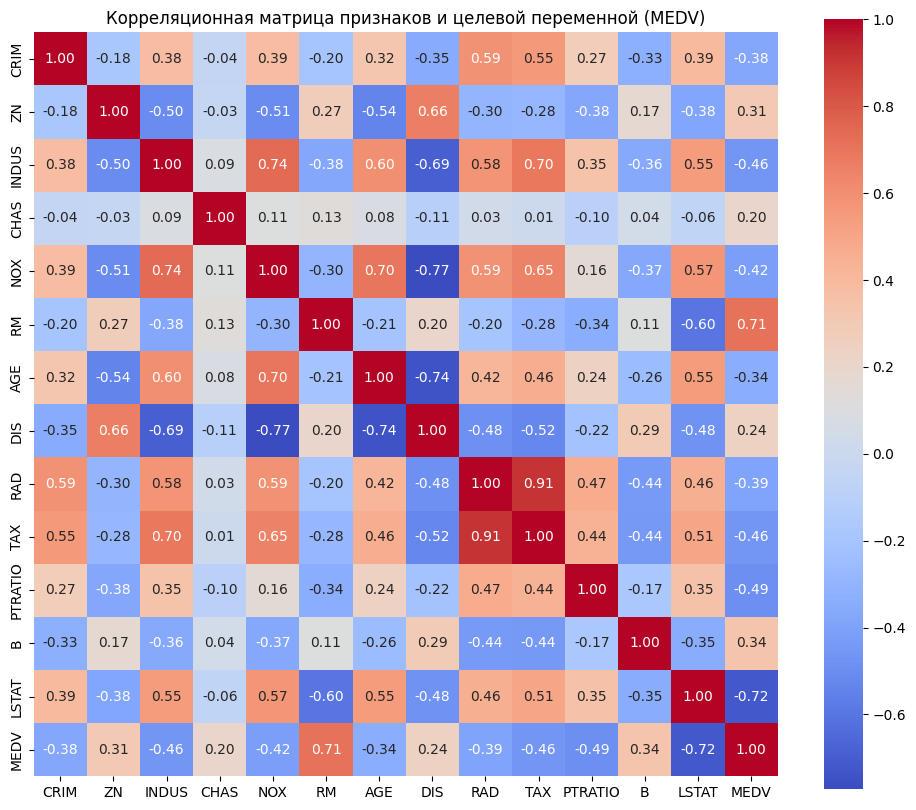

In [37]:

X_imputed_df = pd.DataFrame(X_train_imputed, columns=X.columns)

df_corr = X_imputed_df.copy()
df_corr['MEDV'] = y_train.reset_index(drop=True)

#корреляционная матрица
corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Корреляционная матрица признаков и целевой переменной (MEDV)")
plt.show()

## 7. Выводы
- **Почему выбраны эти метрики?**
  - R² показывает долю дисперсии, объясненную моделью.
  - MAE и RMSE дают представление о среднем размере ошибок в тех же единицах, что и целевая переменная.

- **Сравнение моделей:**
  - Если у одной модели выше R² и ниже MAE/RMSE, она лучше предсказывает.
  - Часто RMSE более чувствителен к крупным ошибкам, MAE — менее.

- **Рекомендации:**
  - Для данной задачи лучше всего себя показала модель случайный лес.
  - Для улучшения качества можно подобрать гиперпараметры, добавить новые признаки или использовать другие алгоритмы.